In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_theme(style="whitegrid", palette="deep")

warnings.filterwarnings('ignore')

In [122]:
df = pd.read_csv('global_supply_chain_risk_2026.csv')
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,10/16/2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,4/24/2024,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,1/26/2024,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,10/8/2024,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,9/7/2024,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64

## Descriptive statistics

In [4]:
df.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


## Verifying data distribution on target feature (Distribution_Occurred)

In [90]:
tf_distribution = df['Disruption_Occurred'].value_counts()
print(tf_distribution)

Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64


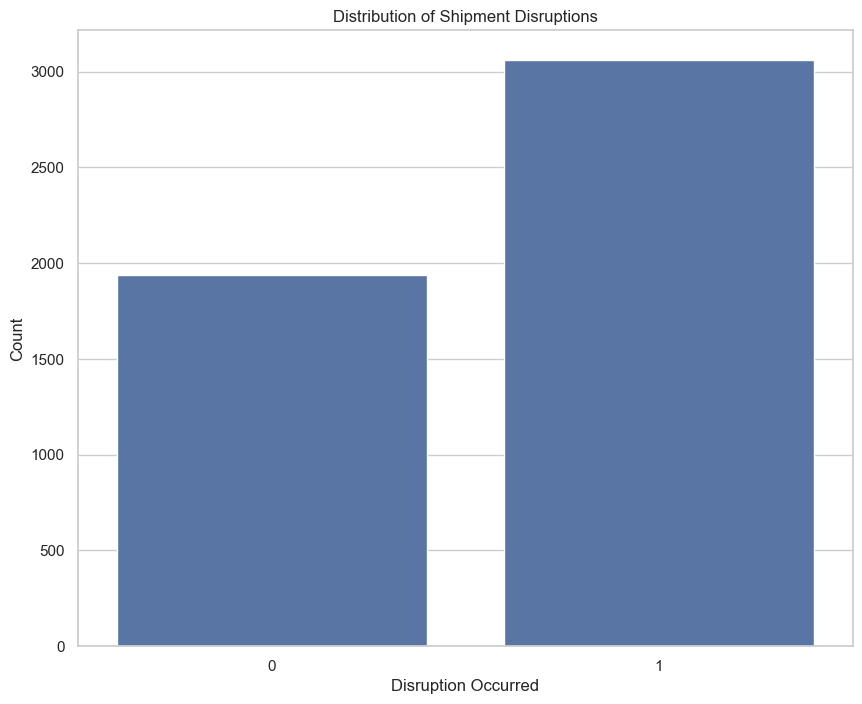

In [89]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x='Disruption_Occurred')
plt.title('Distribution of Shipment Disruptions')
plt.xlabel('Disruption Occurred')
plt.ylabel('Count')

plt.show()

## Feature Engineering

In [123]:
## adding bins for splitting category
df['Fuel_Price_Category'] = pd.cut(
    df['Fuel_Price_Index'],
    bins=[0, 2, 4, float('inf')],
    labels=['Low', 'Medium', 'High']
)

In [124]:
# After transformation
df.head(1)

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Fuel_Price_Category
0,SC-10000,10/16/2025,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,Medium


In [126]:
df.to_excel('global_shipping_data.xlsx', index=False, engine='openpyxl')

## Average lead time by transport mode

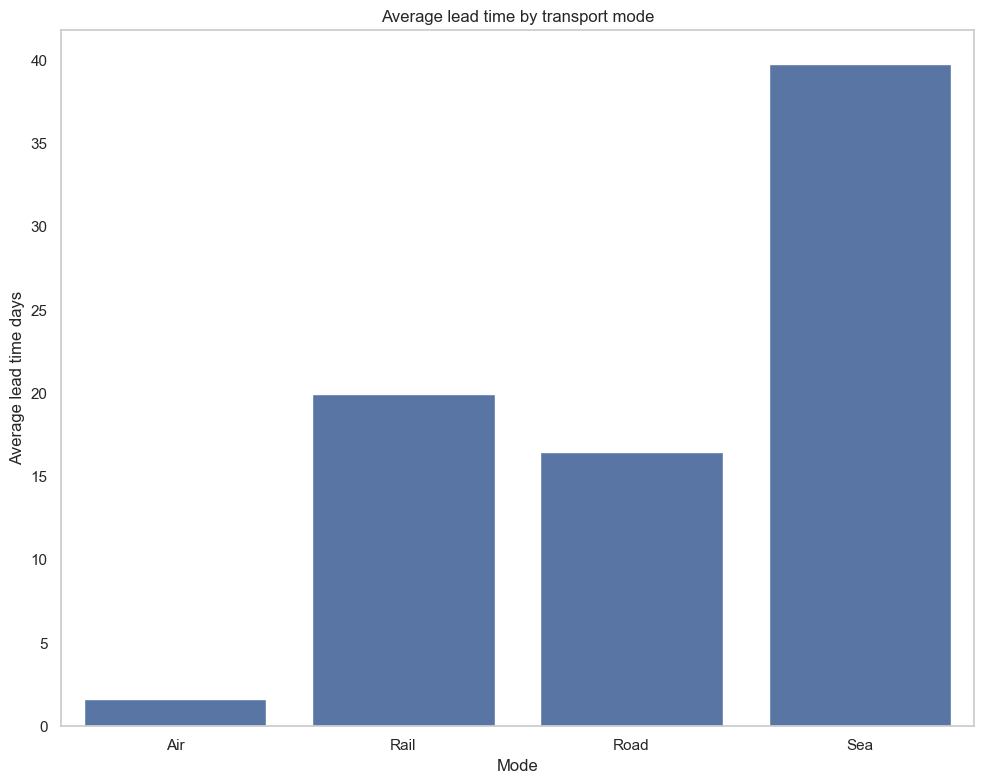

In [23]:
fastest_transport_mode = df.groupby('Transport_Mode')['Lead_Time_Days'].mean()

plt.figure(figsize=(10,8))
sns.barplot(x=fastest_transport_mode.index,
            y=fastest_transport_mode.values)

plt.title('Average lead time by transport mode')
plt.xlabel('Mode')
plt.ylabel('Average lead time days')
plt.tight_layout()
plt.grid(False)
plt.show()

## Routes with longest lead time

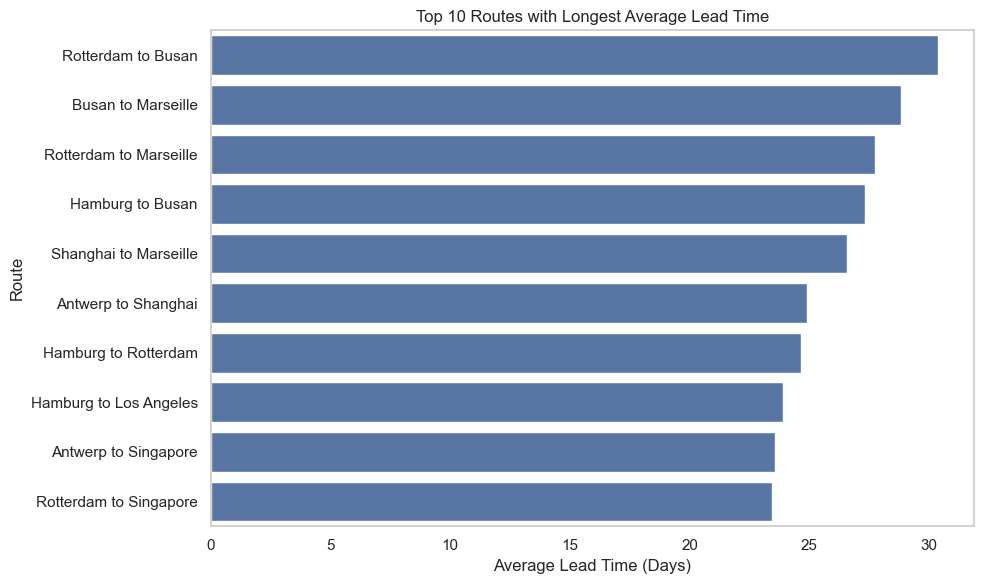

In [54]:
top_ten_route_mean = (
    df.groupby(['Origin_Port', 'Destination_Port'])['Lead_Time_Days']
      .mean()
      .nlargest(10)
)

plot_df = top_ten_route_mean.reset_index()
plot_df['Route'] = (
    plot_df['Origin_Port']
    + ' to '
    + plot_df['Destination_Port']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_df,
    y='Route',
    x='Lead_Time_Days'
)

plt.title('Top 10 Routes with Longest Average Lead Time')
plt.xlabel('Average Lead Time (Days)')
plt.ylabel('Route')
plt.grid(False)
plt.tight_layout()
plt.show()

## Product vs lead time

## Which product categories have the longest lead times?

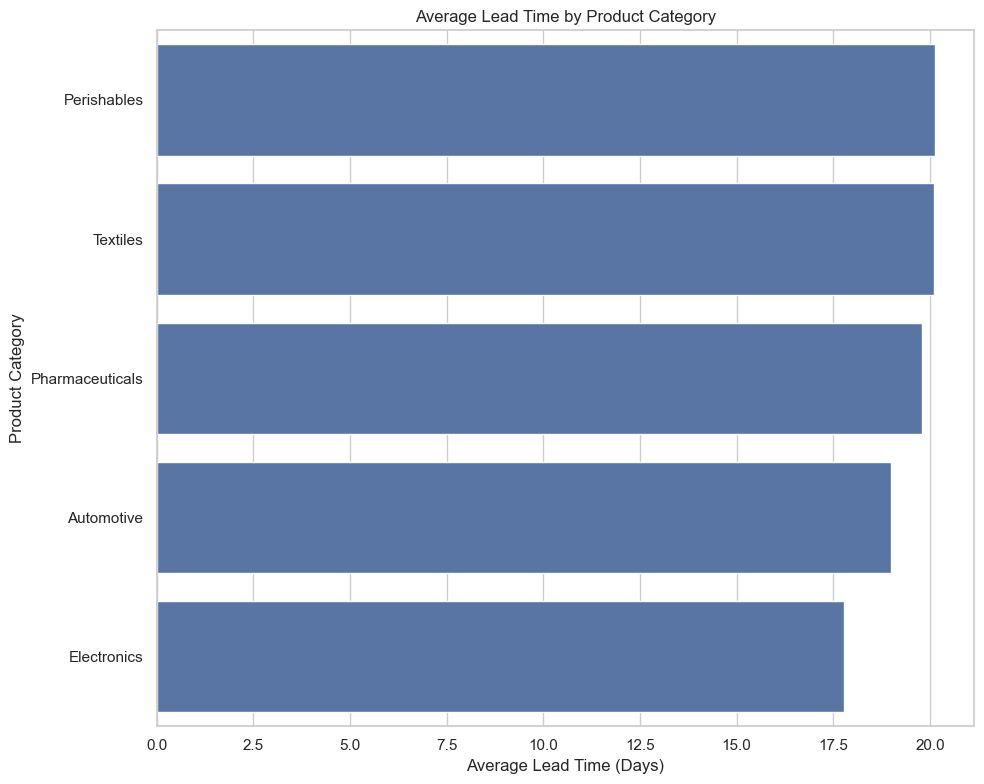

In [61]:
product_lead_time = (df.groupby('Product_Category')['Lead_Time_Days'].mean().sort_values(ascending=False).reset_index())

plt.figure(figsize=(10,8))

sns.barplot(
    data=product_lead_time,
    x='Lead_Time_Days',
    y='Product_Category'
)

plt.title('Average Lead Time by Product Category')
plt.xlabel('Average Lead Time (Days)')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

## Weather Impact

In [30]:
weather_impact = df.groupby('Weather_Condition')['Lead_Time_Days'].mean()
weather_impact

Weather_Condition
Clear         6.698704
Fog           9.892847
Hurricane    53.501848
Rain          7.736049
Storm        19.299182
Name: Lead_Time_Days, dtype: float64

## Weight Impact

## How does weight affect lead time?

In [34]:
weight_impact = df.groupby('Weight_MT')['Lead_Time_Days'].mean()
weight_impact

Weight_MT
1.03       1.230000
1.12      19.943333
1.20      18.135000
1.36       6.560000
1.39       2.510000
            ...    
499.45     0.500000
499.60     1.180000
499.68    11.200000
499.73     8.710000
499.75     8.360000
Name: Lead_Time_Days, Length: 4785, dtype: float64

## Risk impact

    Does risk increase lead time?

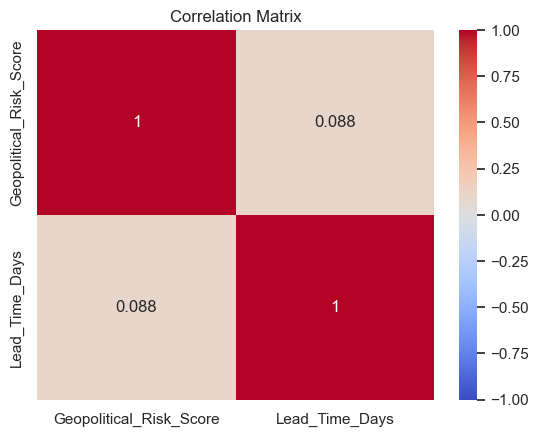

In [43]:
corr = df[['Geopolitical_Risk_Score',
           'Lead_Time_Days']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.title('Correlation Matrix')
plt.show()

## Carrier Performance

## Do reliable carriers reduce delays?

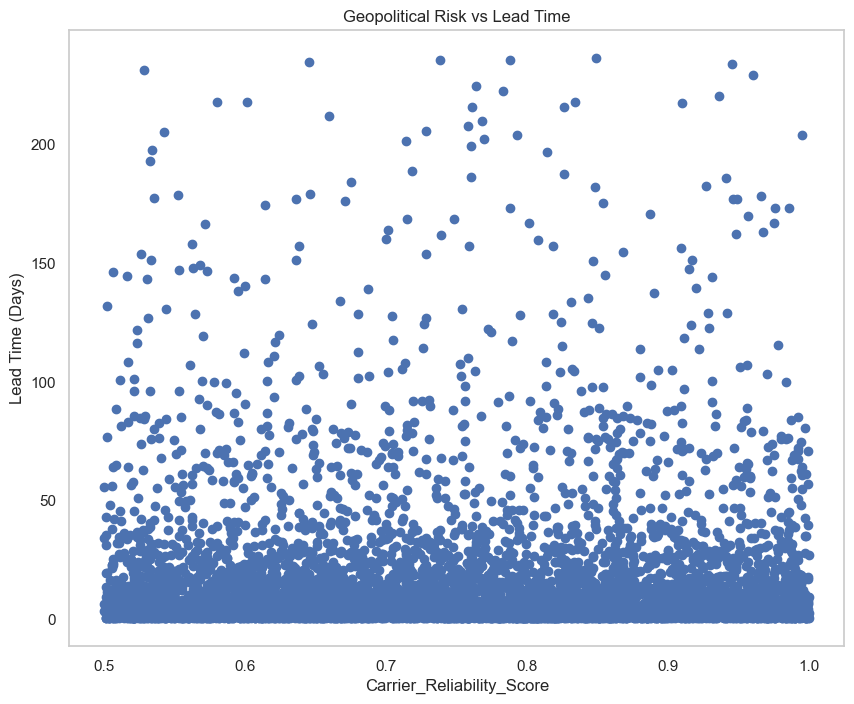

In [73]:
plt.figure(figsize=(10,8))
plt.scatter(df['Carrier_Reliability_Score'],
            df['Lead_Time_Days'])
plt.xlabel('Carrier_Reliability_Score')
plt.ylabel('Lead Time (Days)')
plt.grid(False)
plt.title('Geopolitical Risk vs Lead Time')
plt.show()

## Distance impact

## Does longer distance increase lead time?

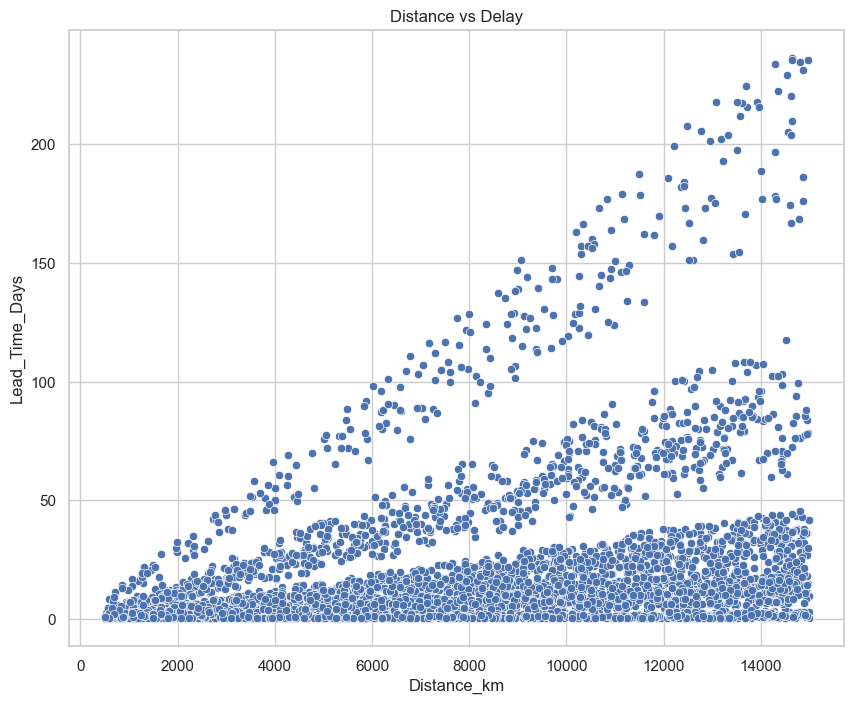

In [66]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df,
    x='Distance_km',
    y='Lead_Time_Days'
)

plt.title("Distance vs Delay")
plt.show()

## Which product categories suffer most during high fuel price periods?

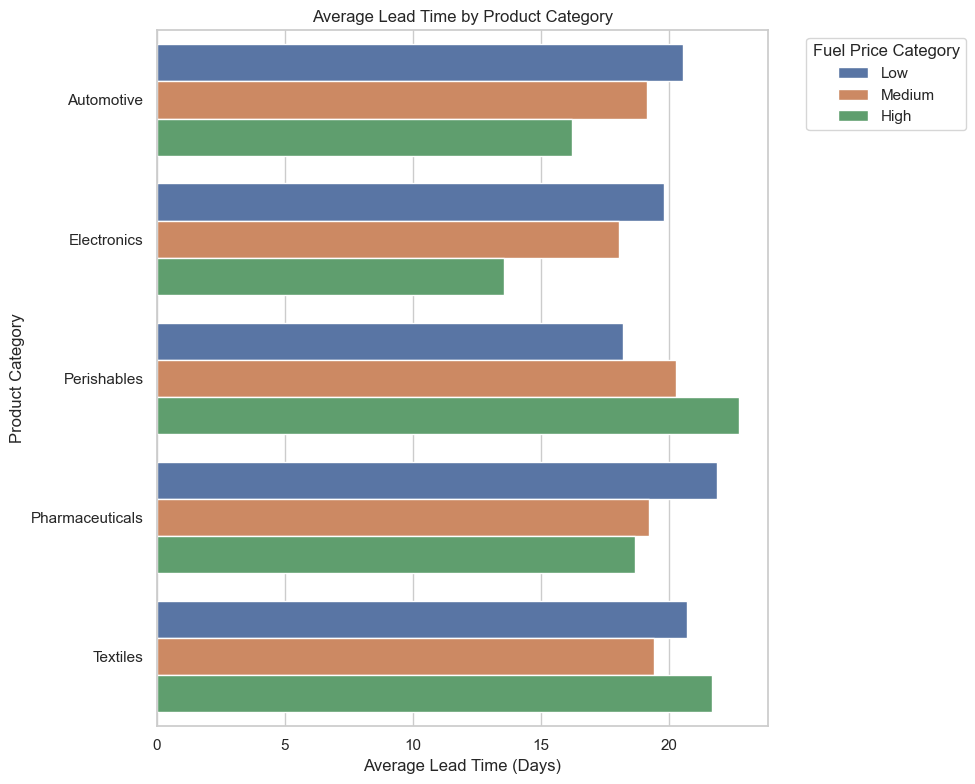

In [74]:
product_fuel_price = (
    df.groupby([
        'Fuel_Price_Category',
        'Product_Category'
    ])['Lead_Time_Days']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=product_fuel_price,
    x='Lead_Time_Days',
    y='Product_Category',
    hue='Fuel_Price_Category'

)

plt.title('Average Lead Time by Product Category')
plt.xlabel('Average Lead Time (Days)')
plt.ylabel('Product Category')

plt.legend(
    title='Fuel Price Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## Exploring Relationships Among Logistics and Transportation Metrics

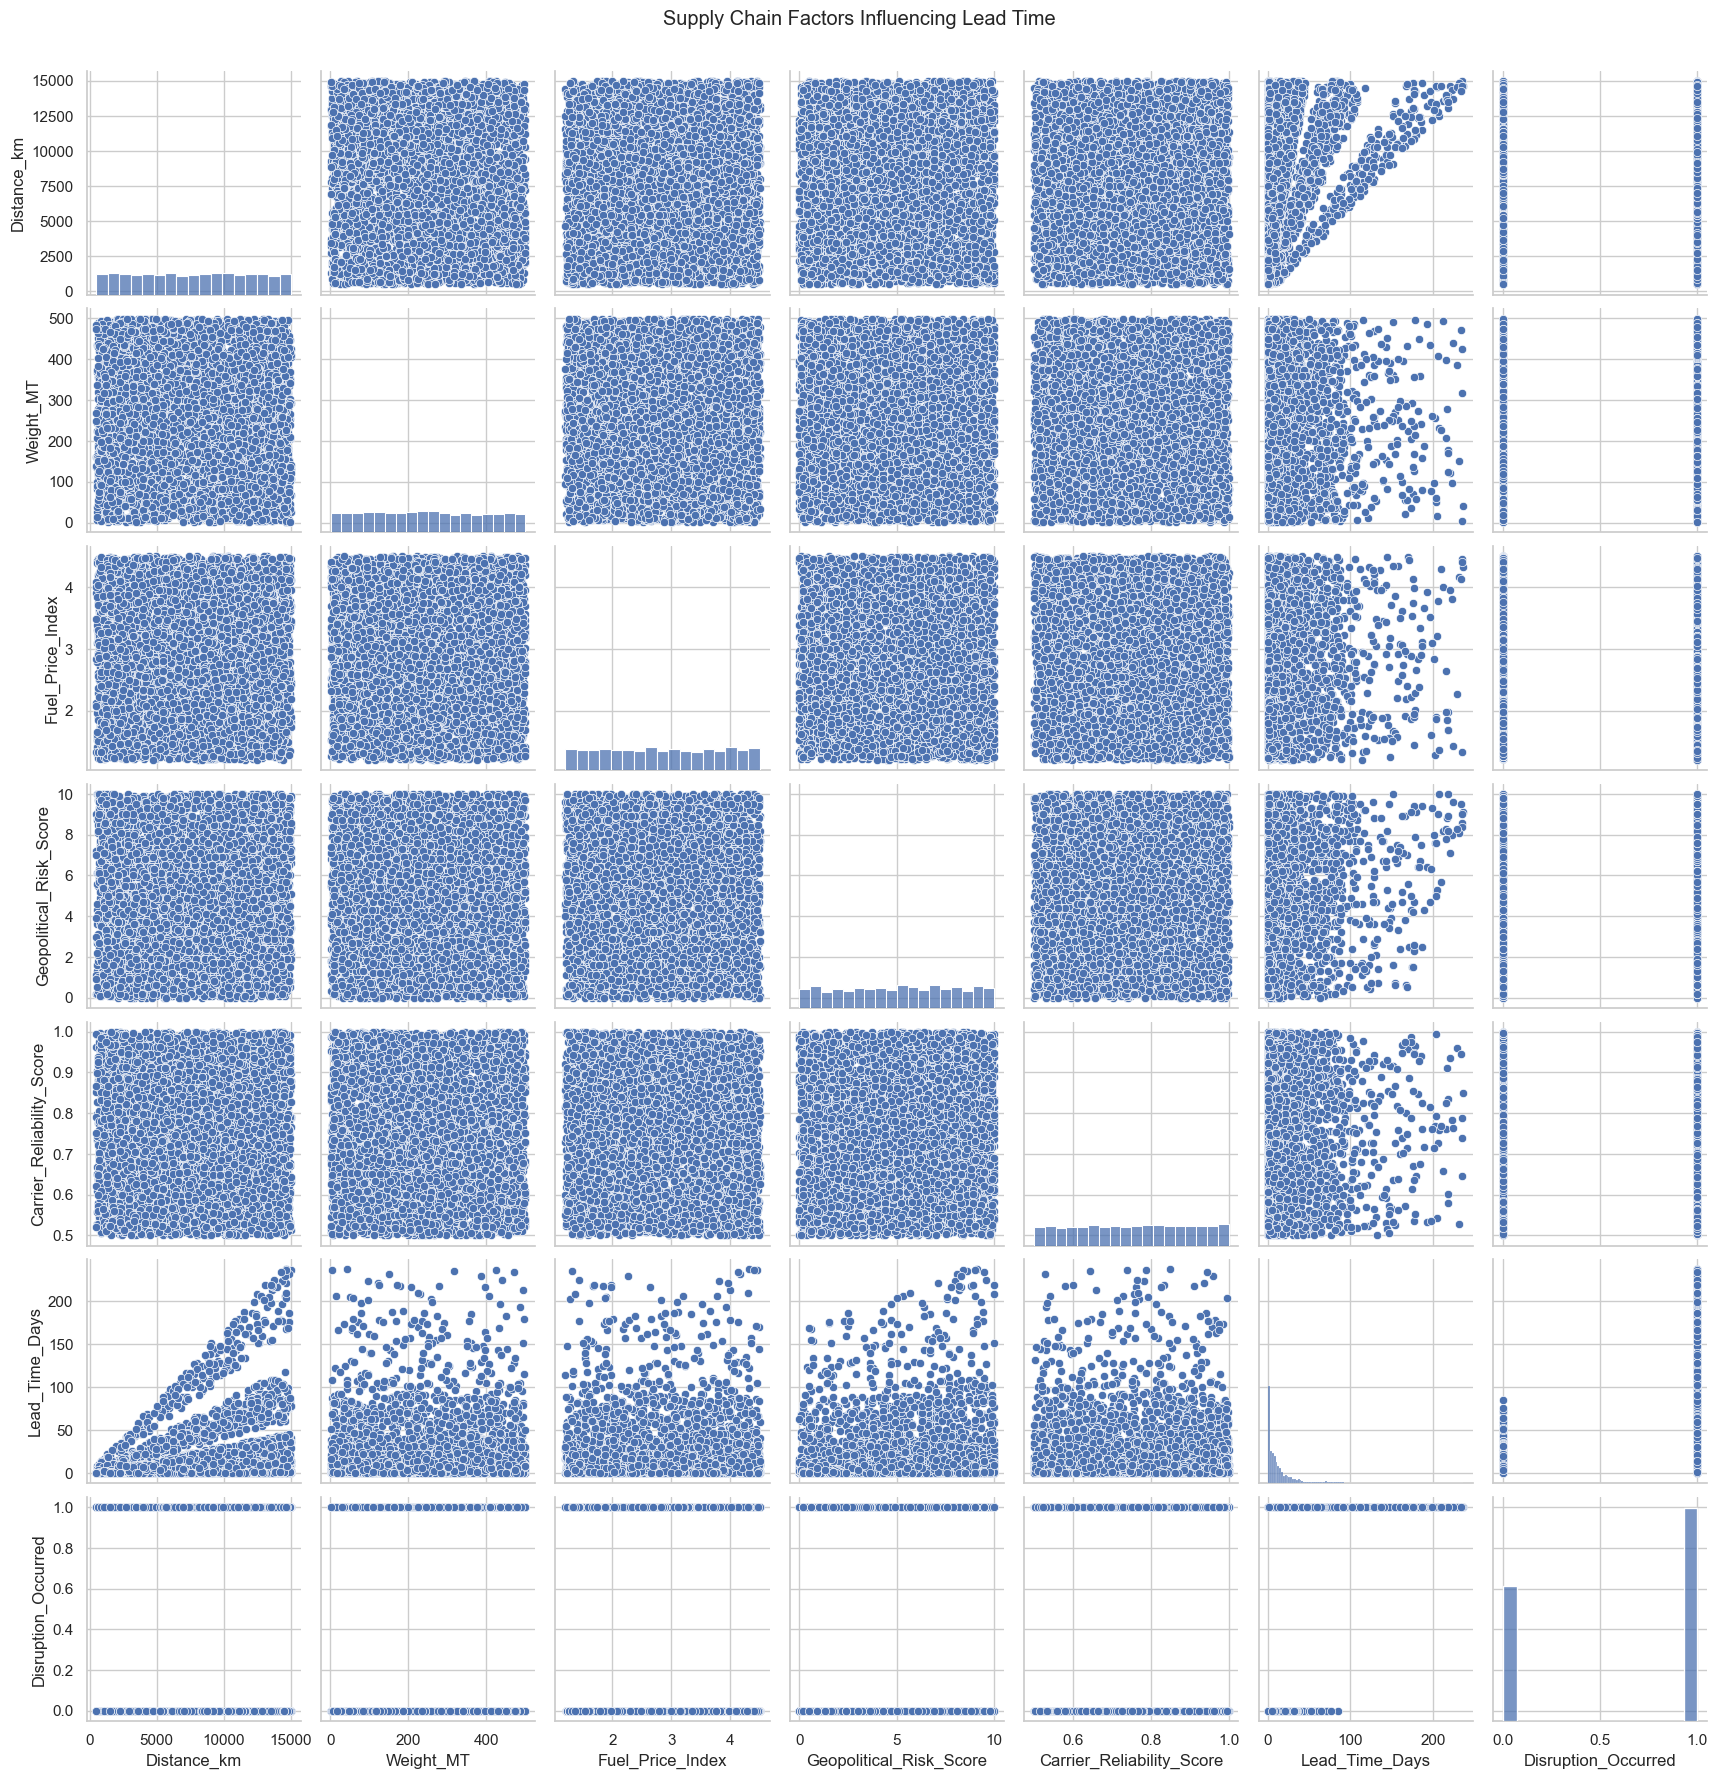

In [76]:
pair_plot = sns.pairplot(df)
plt.suptitle(
    'Supply Chain Factors Influencing Lead Time',
    y=1.02
)
plt.show()

## Machine Learning Project

        ## Disruption prediction based on transport mode, weather condition, carrier reliablity, geopolitical risk, fuel price, weight and distance criteria. 


In [116]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

In [110]:
features = [
    'Distance_km',
    'Weight_MT',
    'Fuel_Price_Index',
    'Geopolitical_Risk_Score',
    'Carrier_Reliability_Score',
    'Weather_Condition',
    'Transport_Mode'
]

X = df[features]

# encode category variable

X = pd.get_dummies(X, columns = ['Weather_Condition', 'Transport_Mode'], drop_first= True)

y = df['Disruption_Occurred']

In [114]:
# Step 1: Split the original data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

# Step 2: Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight = 'balanced'
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

Disruption_Occurred
0    2442
1    2442
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.61      0.76      0.68       379
           1       0.83      0.71      0.76       621

    accuracy                           0.73      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.75      0.73      0.73      1000



<Figure size 1000x800 with 0 Axes>

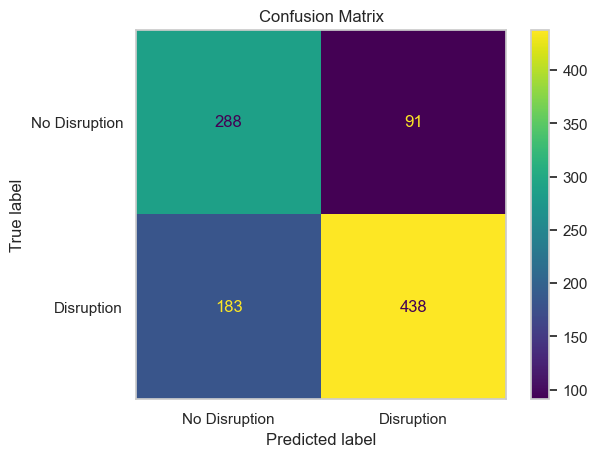

In [115]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disruption', 'Disruption']
)

disp.plot()
plt.grid(False)

plt.title('Confusion Matrix')
plt.show()

In [117]:
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0       0.59      0.71      0.64       379
           1       0.80      0.69      0.74       621

    accuracy                           0.70      1000
   macro avg       0.69      0.70      0.69      1000
weighted avg       0.72      0.70      0.70      1000



<Figure size 1000x800 with 0 Axes>

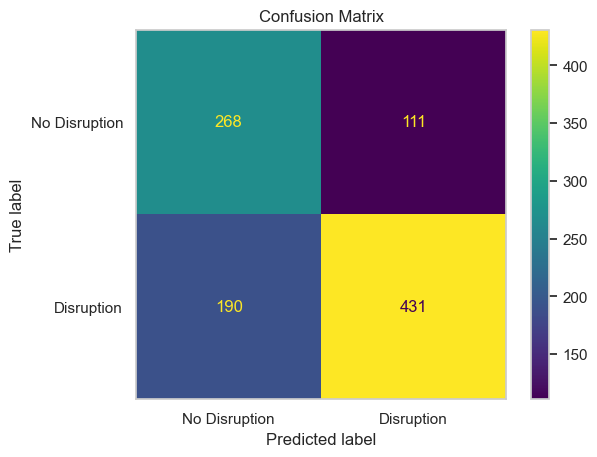

In [118]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Disruption', 'Disruption']
)

disp.plot()
plt.grid(False)

plt.title('Confusion Matrix')
plt.show()

In [119]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7942419877718719


Power BI Dashboard
Page 1: Executive Summary

KPIs:

Total Shipments
Average Lead Time
Average Distance
Disruption Rate
Average Reliability Score

Visuals:

Monthly Shipments
Shipment by Transport Mode
Shipment by Product Category

Page 2: Transportation Analysis

Questions:

Which transport mode is most efficient?

Visual:

Transport Mode
vs
Lead Time
Which transport mode has most disruptions?

Visual:

Transport Mode
vs
Disruption Rate
Page 3: Risk Analysis

KPIs:

Average Risk Score
Average Fuel Index

Visuals:

Risk vs Lead Time

Scatter chart

Weather Impact

Bar chart

Weather Condition
vs
Lead Time
Page 4: Route Performance

Visuals:

Top 10 Slowest Routes
Origin → Destination
Top 10 Fastest Routes
Page 5: Disruption Analytics 

Questions:

What factors drive disruptions?

Visuals:

Disruptions by Weather
Disruptions by Transport Mode
Disruptions by Product Category

KPI:

Disruption Rate %